<a href="https://colab.research.google.com/github/KhanAmmarAhmed/Ai-ML/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 3 : Task 3: Heart Disease Prediction

<>:52: SyntaxWarning: invalid escape sequence '\?'
<>:52: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_13716/509486344.py:52: SyntaxWarning: invalid escape sequence '\?'
  if df[col].astype(str).str.contains('\?').any(): # Check if '?' exists in values


Libraries Loaded Successfully

--- Starting Data Cleaning and Preprocessing ---
Filled missing values in 'trestbps' with median: 130.0
Filled missing values in 'chol' with median: 223.0
Filled missing values in 'thalch' with median: 140.0
Filled missing values in 'oldpeak' with median: 0.5
Filled missing values in 'ca' with median: 0.0
Filled missing values in 'fbs' with mode: False
Filled missing values in 'restecg' with mode: normal
Filled missing values in 'exang' with mode: False
Filled missing values in 'slope' with mode: flat
Filled missing values in 'thal' with mode: normal

Missing values after imputation:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Target variable 'num' binarized and renamed to 'heart_disease'.
heart_disease
1    509
0    411
Name: count, dtype: int64

Categorical features have been 

/tmp/ipykernel_13716/509486344.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_13716/509486344.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

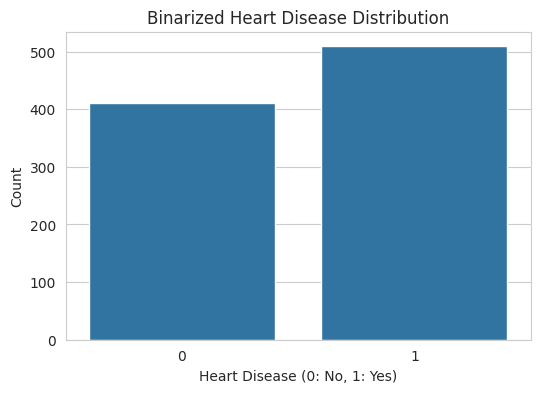

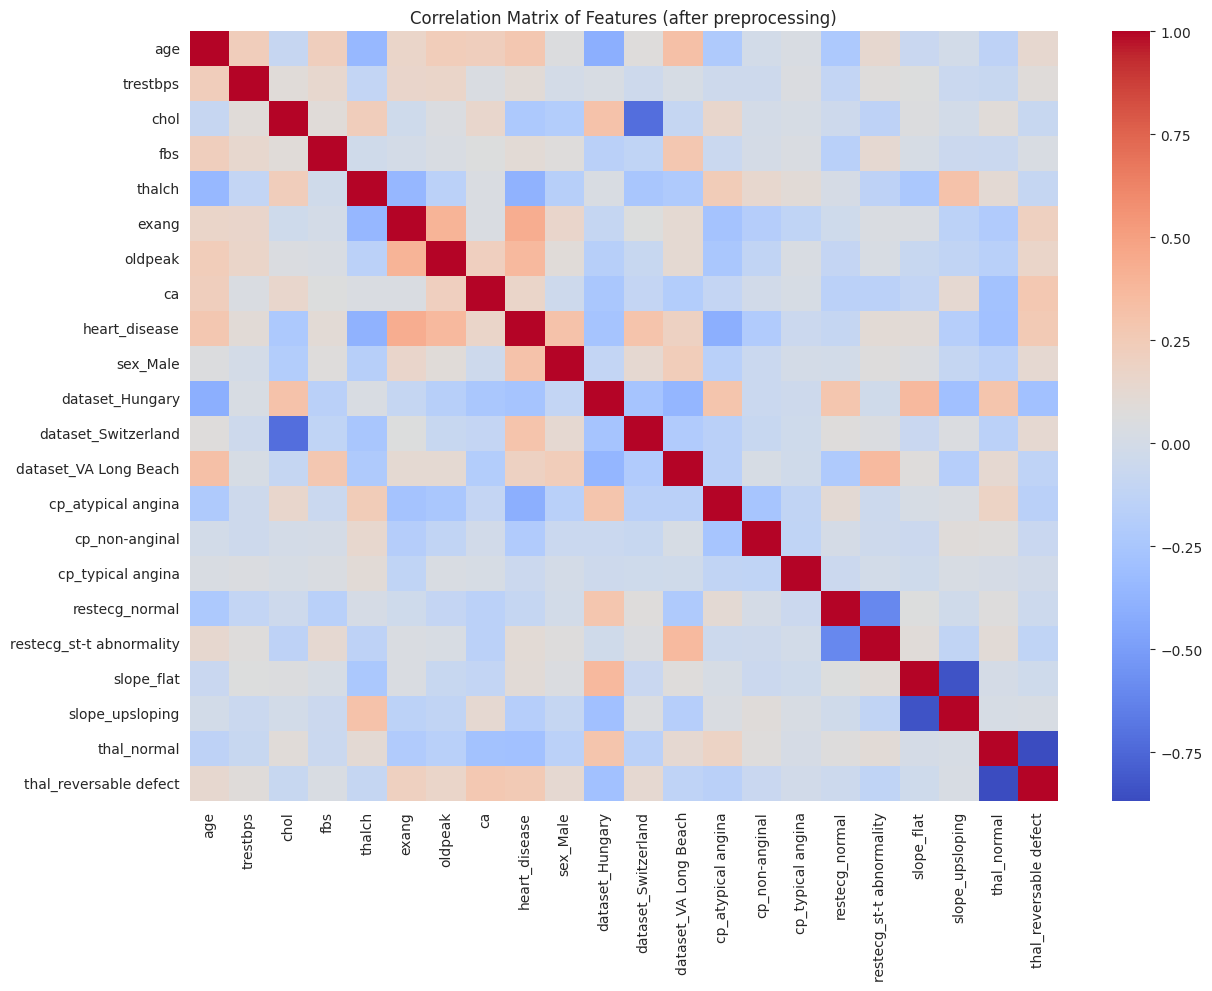

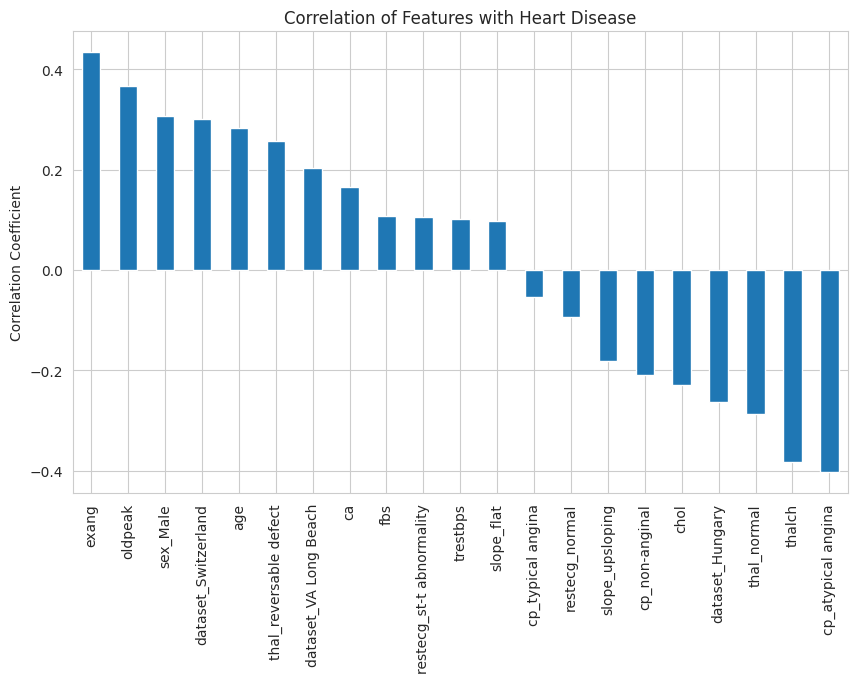


--- EDA Complete ---

--- Starting Model Training and Evaluation ---
Training set shape: (736, 21), Test set shape: (184, 21)

--- Logistic Regression Model ---
Accuracy (Logistic Regression): 0.8369565217391305

Confusion Matrix (Logistic Regression):
 [[63 19]
 [11 91]]

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

ROC-AUC Score (Logistic Regression): 0.9216

--- Decision Tree Classifier Model ---
Accuracy (Decision Tree): 0.7934782608695652

Confusion Matrix (Decision Tree):
 [[56 26]
 [12 90]]

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.82      0.68      0.75        82
           1      

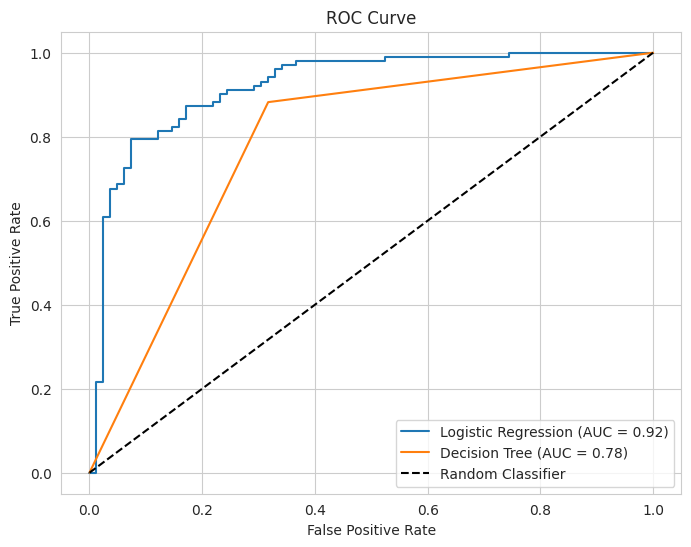


--- Model Training and Evaluation Complete ---

--- Highlighting Important Features ---


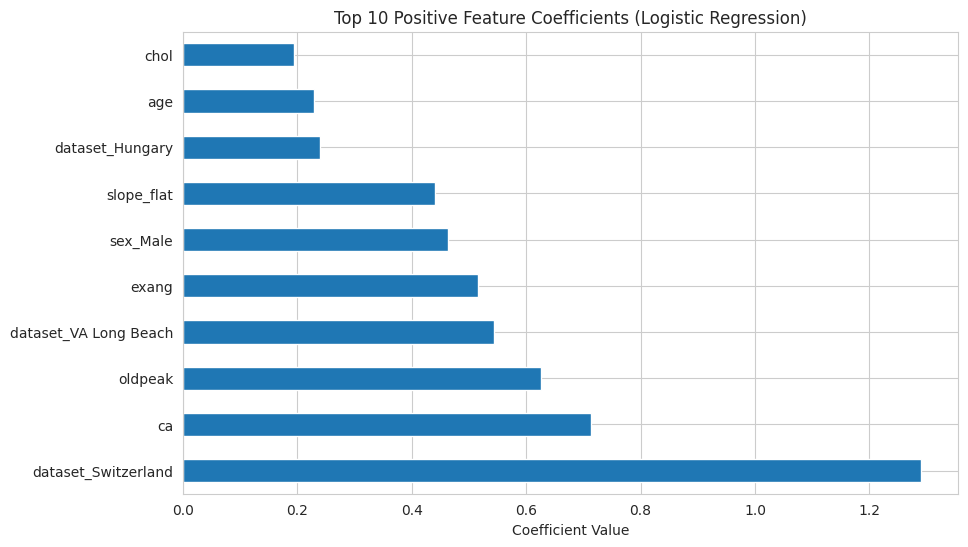

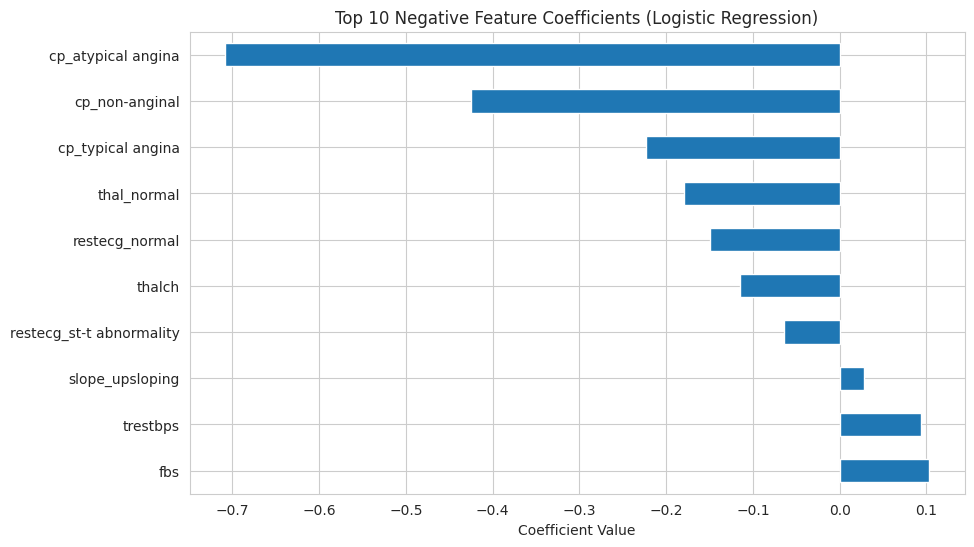

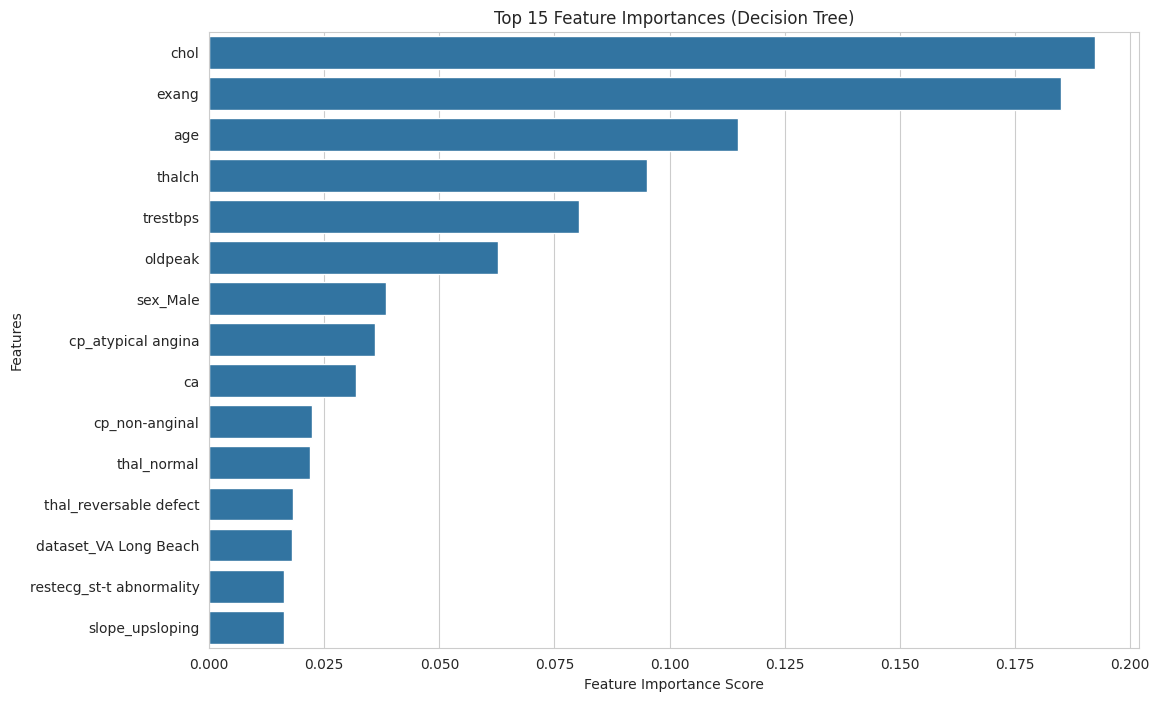


--- Feature Importance Analysis Complete ---


In [17]:
# Install libraries if needed
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

# --- Start of solution for user's request: Heart Disease Prediction Workflow ---

print("\n--- Starting Data Cleaning and Preprocessing ---")

# Drop 'id' column as it's an identifier and not useful for prediction
df = df.drop('id', axis=1)

# Handle missing values
# Impute numerical columns with median
numerical_cols_to_impute_median = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numerical_cols_to_impute_median:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Impute categorical columns with mode
categorical_cols_to_impute_mode = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols_to_impute_mode:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # mode() returns a Series, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# Check for any remaining '?' or non-standard missing indicators in object columns
# Replace '?' with NaN and then impute
for col in df.select_dtypes(include='object').columns:
    if df[col].astype(str).str.contains('\?').any(): # Check if '?' exists in values
        df[col].replace('?', np.nan, inplace=True)
        if df[col].isnull().any():
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Replaced '?' and filled missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

# Binarize the target variable 'num' (0: no disease, 1: disease)
# Assuming 0 means no disease and >0 means some form of heart disease
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.rename(columns={'num': 'heart_disease'})
print("\nTarget variable 'num' binarized and renamed to 'heart_disease'.")
print(df['heart_disease'].value_counts())

# Convert categorical features to one-hot encoding
# Identify categorical columns (excluding the new binary target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Check if 'dataset' column has more than one unique value; if not, it's not a useful feature.
if 'dataset' in categorical_cols and df['dataset'].nunique() == 1:
    df = df.drop('dataset', axis=1)
    categorical_cols.remove('dataset')
    print("Dropped 'dataset' column as it contains only one unique value.")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nCategorical features have been one-hot encoded.")
print("DataFrame shape after encoding:", df.shape)

print("\n--- Data Cleaning and Preprocessing Complete ---")

print("\n--- Starting Exploratory Data Analysis (EDA) ---")

# Distribution of the binarized target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df)
plt.title("Binarized Heart Disease Distribution")
plt.xlabel("Heart Disease (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

# Correlation matrix (after cleaning and encoding)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f') # Set annot=False due to potentially many features after one-hot encoding
plt.title("Correlation Matrix of Features (after preprocessing)")
plt.show()

# Example: Correlation of features with the target variable
plt.figure(figsize=(10, 6))
df.corr()['heart_disease'].drop('heart_disease').sort_values(ascending=False).plot(kind='bar')
plt.title("Correlation of Features with Heart Disease")
plt.ylabel("Correlation Coefficient")
plt.show()

print("\n--- EDA Complete ---")

print("\n--- Starting Model Training and Evaluation ---")

# Define features (X) and target (y)
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for feature importance interpretation (optional but good for consistency)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# --- Logistic Regression ---
print("\n--- Logistic Regression Model ---")
lr_model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets
lr_model.fit(X_train_scaled_df, y_train)
y_pred_lr = lr_model.predict(X_test_scaled_df)
y_prob_lr = lr_model.predict_proba(X_test_scaled_df)[:, 1]

print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))

# ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC Score (Logistic Regression): {auc_lr:.4f}")

# --- Decision Tree Classifier ---
print("\n--- Decision Tree Classifier Model ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled_df, y_train)
y_pred_dt = dt_model.predict(X_test_scaled_df)
y_prob_dt = dt_model.predict_proba(X_test_scaled_df)[:, 1]

print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix (Decision Tree):\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report (Decision Tree):\n", classification_report(y_test, y_pred_dt))

# ROC Curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"ROC-AUC Score (Decision Tree): {auc_dt:.4f}")

# Plotting ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\n--- Model Training and Evaluation Complete ---")

print("\n--- Highlighting Important Features ---")

# Feature importance for Logistic Regression (coefficients)
# Coefficients for scaled data represent feature importance
lr_feature_importance = pd.Series(lr_model.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
lr_feature_importance.head(10).plot(kind='barh') # Top 10 positive influence
plt.title("Top 10 Positive Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()

plt.figure(figsize=(10, 6))
lr_feature_importance.tail(10).plot(kind='barh') # Top 10 negative influence
plt.title("Top 10 Negative Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()


# Feature importance for Decision Tree
dt_feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=dt_feature_importance.head(15), y=dt_feature_importance.head(15).index)
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()

print("\n--- Feature Importance Analysis Complete ---")

# --- End of solution ---


### Confusion Matrix for Logistic Regression

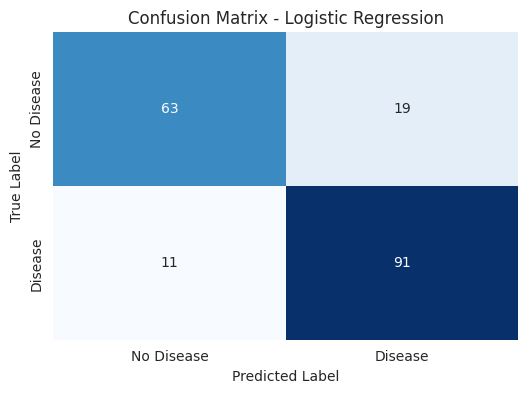

In [18]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [7]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (1).csv


In [9]:
df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [11]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [12]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


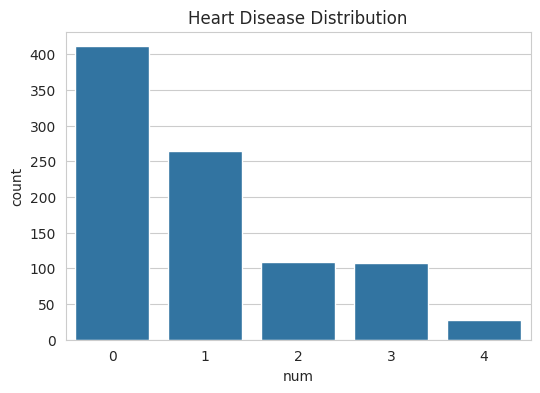

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.show()

print(df['num'].value_counts())

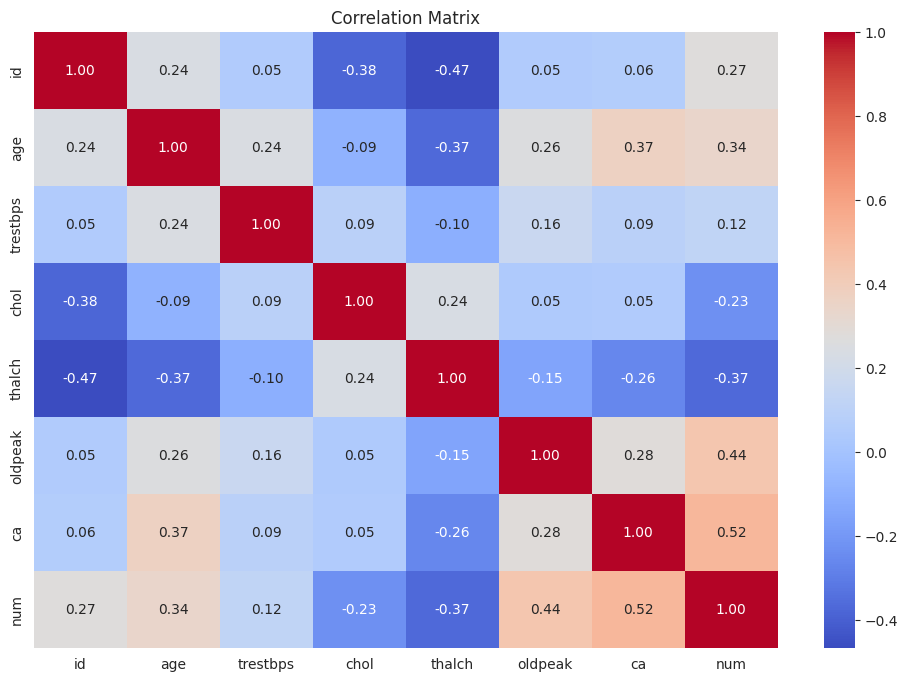

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()